In [2]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [3]:
import pandas as pd
df_quasar = pd.read_csv("galaxyquasar.csv")

df_quasar

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [4]:
#taking just the float part of dataset

data_color = df_quasar.to_numpy()
cleaned_data_color = np.column_stack((data_color[:,0], data_color[:,1], data_color[:,2], data_color[:,3], data_color[:,4]))
float_data = np.asfarray(cleaned_data_color, dtype = float)

Creating array for class labels

In [5]:
data_labels = data_color[:,5]
count = 0
labels = np.zeros(np.size(data_labels))
for i in range (np.size(data_labels)):
    if (data_labels[i] == 'QSO'):
        labels[i] = 1 


#### Creating arrays for colors

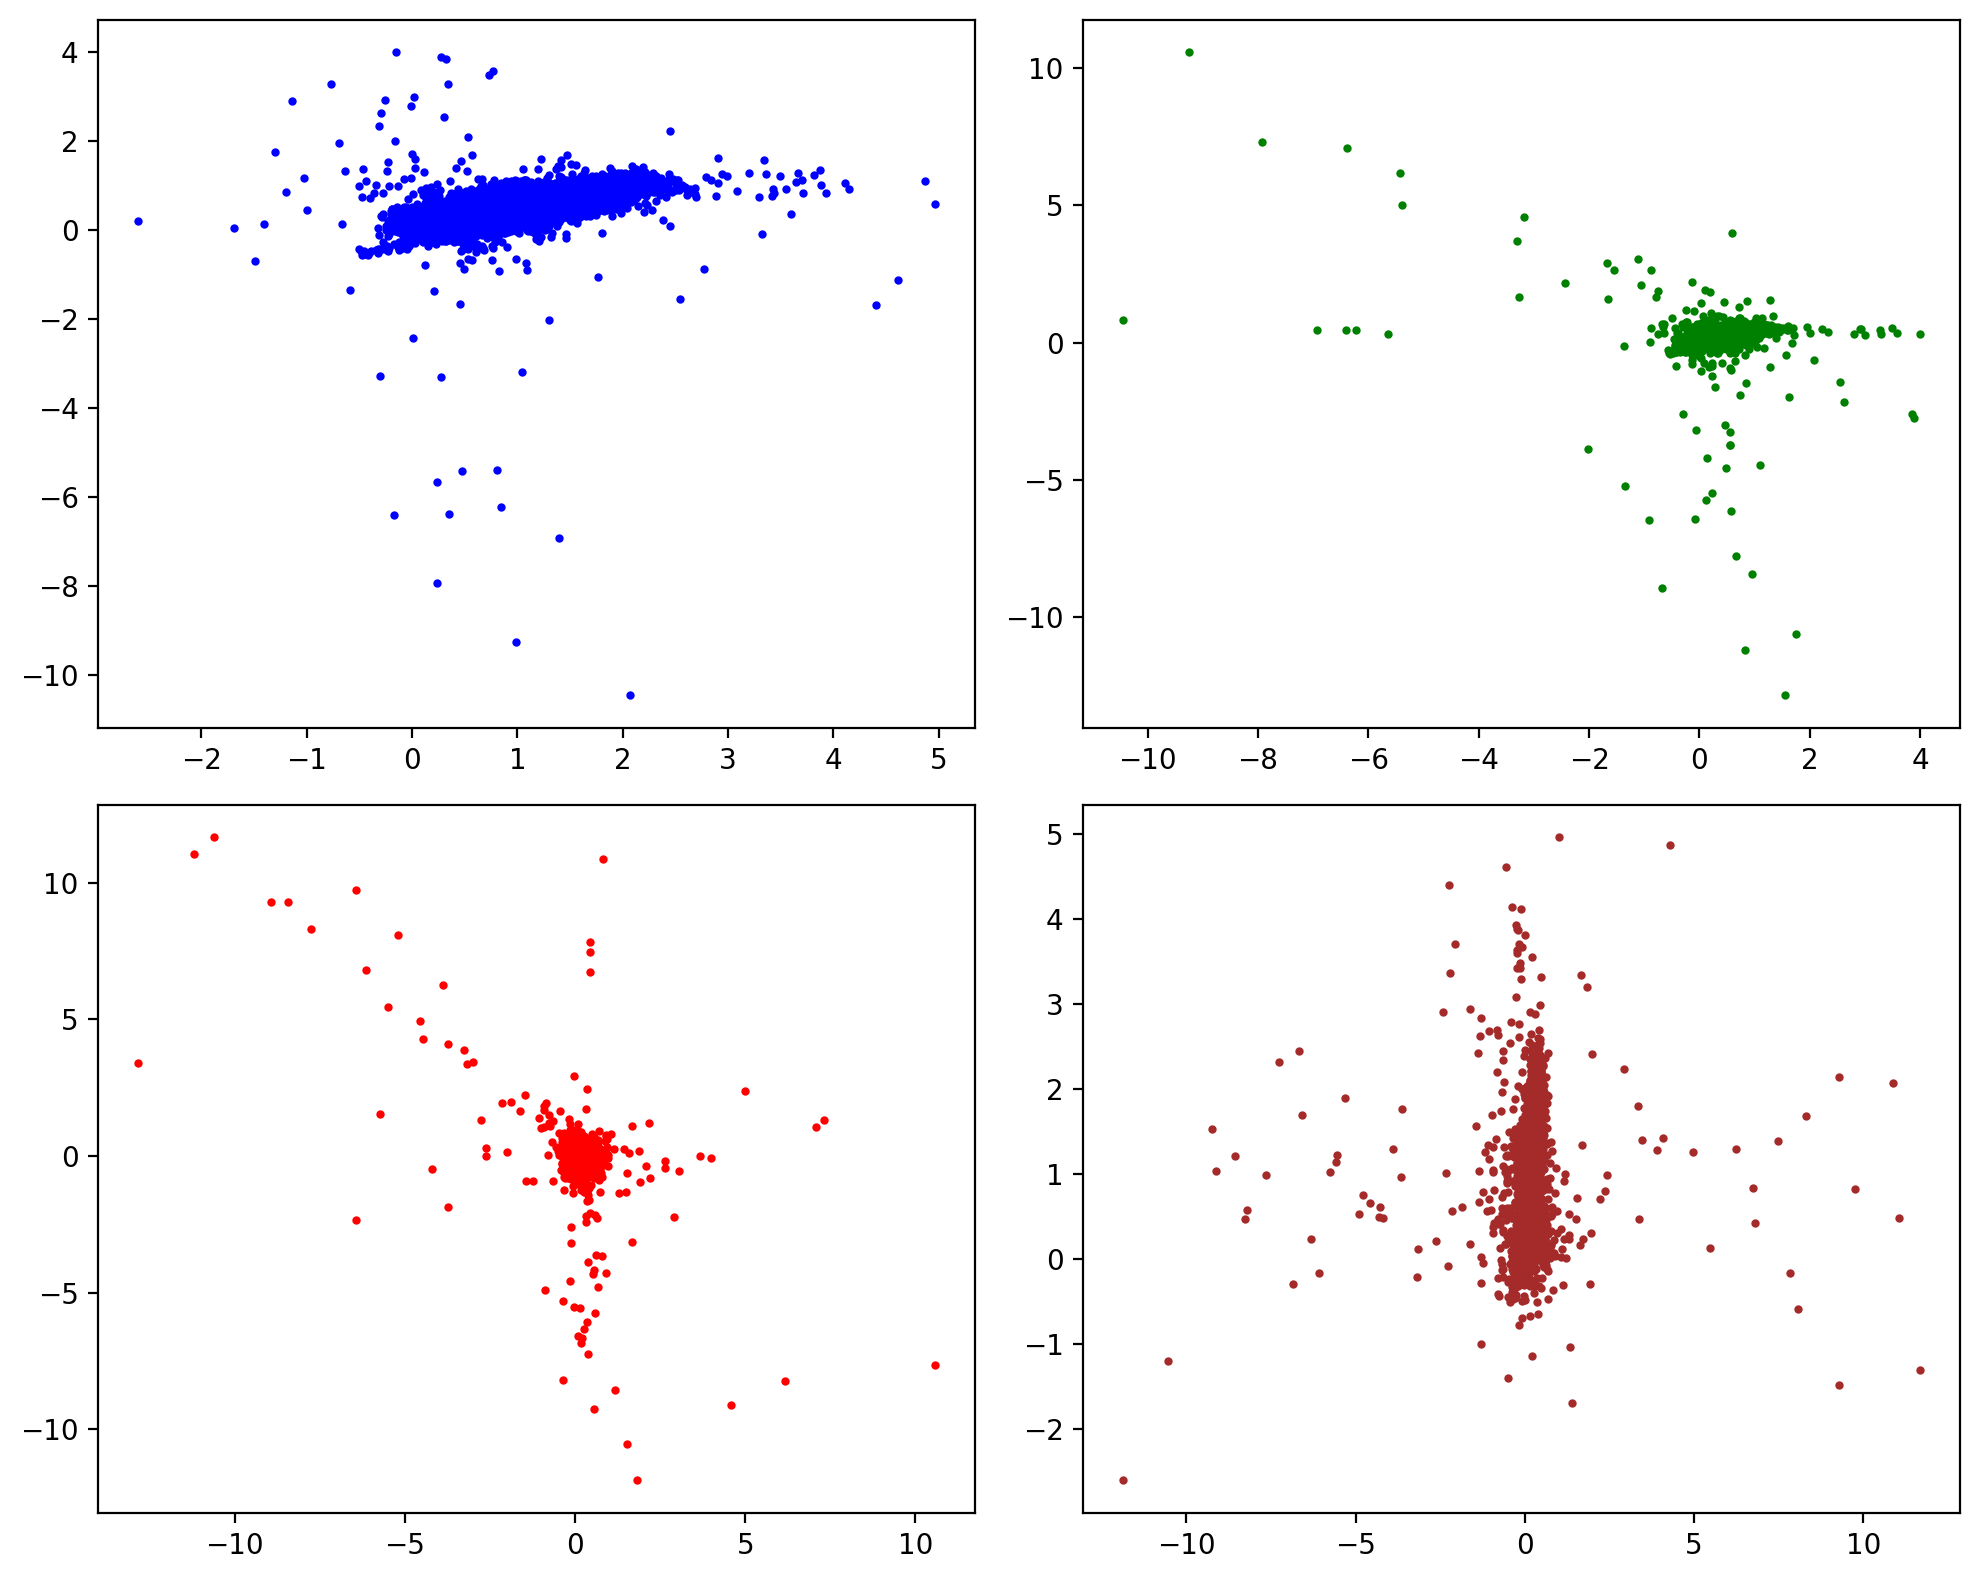

array([0.4353699999999989, -0.04603999999999786, 0.2334399999999981,
       0.057210000000001315], dtype=object)

In [7]:
u_g = (data_color[:,0] - data_color[:,1])

g_r = (data_color[:,1]- data_color[:,2])

r_i = (data_color[:,2]- data_color[:,3])

i_z = (data_color[:,3]- data_color[:,4])

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

axes[0][0].scatter(u_g, g_r, color='blue', s = 4)

axes[0][1].scatter(g_r, r_i, color='green', s = 4)

axes[1][0].scatter(r_i, i_z, color='red', s = 4)

axes[1][1].scatter(i_z, u_g, color='brown', s = 4)

plt.tight_layout()


data = np.column_stack((u_g , g_r , r_i , i_z))
plt.show()
data[0,:]

Let's divide in quasar & galaxies!

In [6]:
quasar = np.zeros((np.size(np.where(labels == 1)), 5))
np.where(labels==1)

(array([    0,     4,     7, ..., 49985, 49990, 49991], dtype=int64),)

In [7]:
q = np.array([])
g = np.array([])
for i in range(np.size(labels)):
    if (labels[i] == 1):
        q = np.append(q , float_data[i,:])
        
    if (labels[i] == 0):
        g = np.append(g , float_data[i,:])

quasar = q.reshape(-1, 5)
galaxy = g.reshape(-1, 5)

Now i can create my quasar and galaxy vectors and see the difference 

In [8]:
Q_u_g = (quasar[:,0] - quasar[:,1])
G_u_g = (galaxy[:,0] - galaxy[:,1])

Q_g_r = (quasar[:,1] - quasar[:,2])
G_g_r = (galaxy[:,1] - galaxy[:,2])

Q_r_i = (quasar[:,2] - quasar[:,3])
G_r_i = (galaxy[:,2] - galaxy[:,3])

Q_i_z = (quasar[:,3] - quasar[:,4])
G_i_z = (galaxy[:,3] - galaxy[:,4])

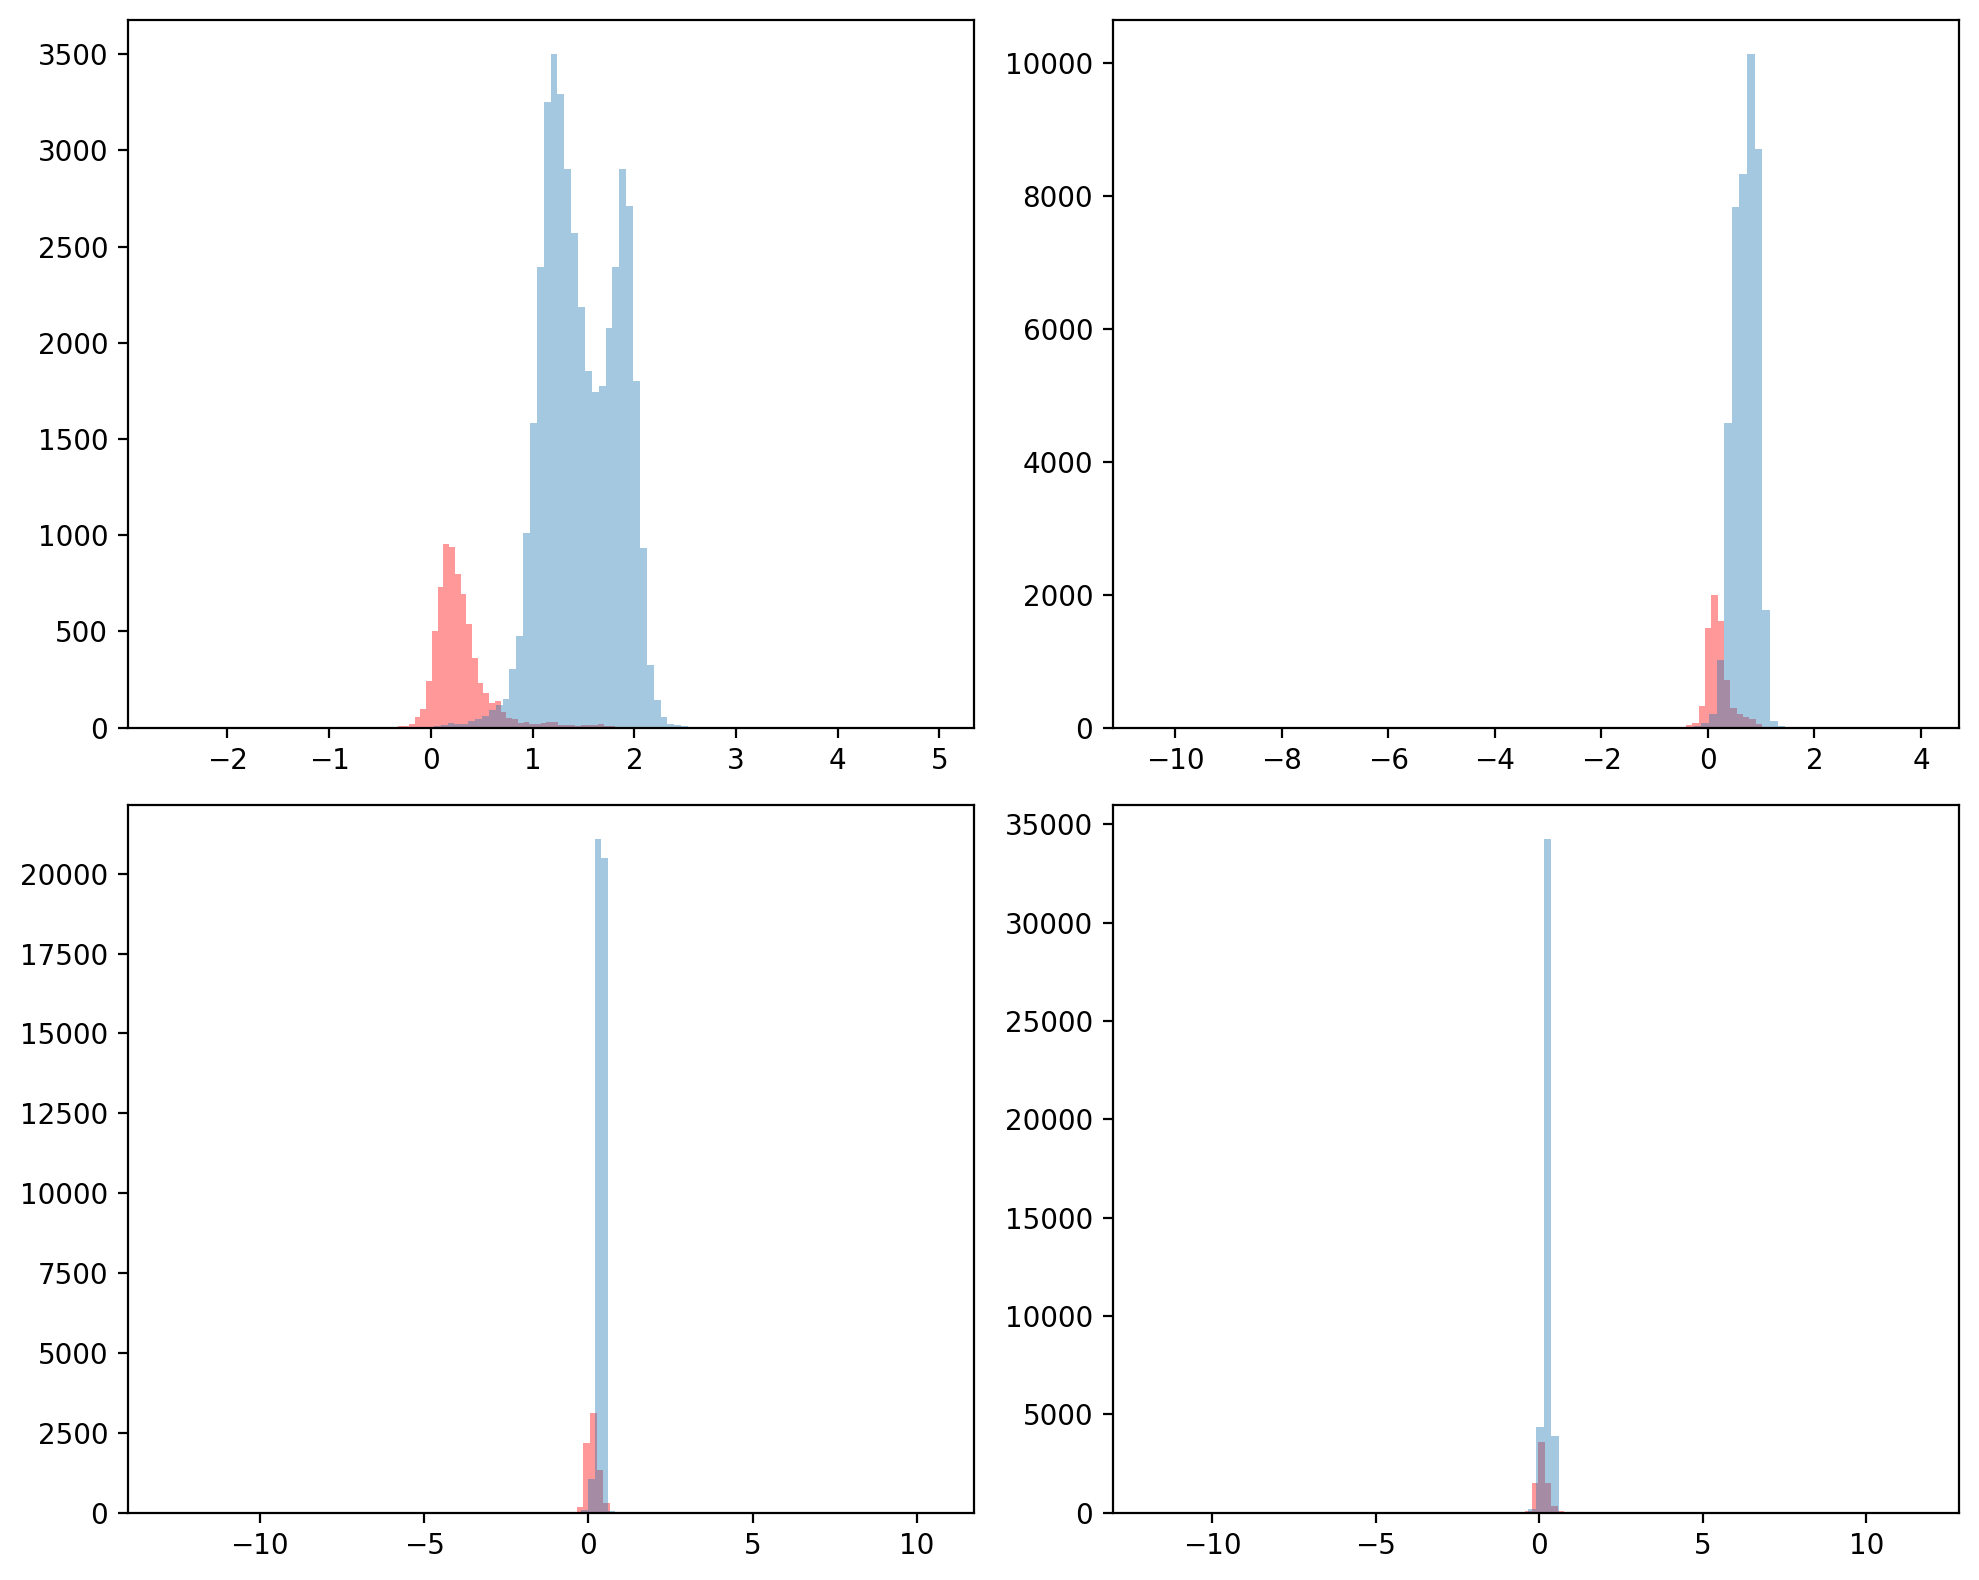

In [9]:
fig, hist2 = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

hist2[0][0].hist(Q_u_g, alpha = 0.4 , bins = 100, color = 'red')
hist2[0][0].hist(G_u_g, alpha = 0.4 , bins = 100)

hist2[0][1].hist(Q_g_r, alpha = 0.4 , bins = 100, color = 'red')
hist2[0][1].hist(G_g_r, alpha = 0.4 , bins = 100)

hist2[1][0].hist(Q_r_i, alpha = 0.4 , bins = 100, color = 'red')
hist2[1][0].hist(G_r_i, alpha = 0.4 , bins = 100)

hist2[1][1].hist(Q_i_z, alpha = 0.4 , bins = 100, color = 'red')
hist2[1][1].hist(G_i_z, alpha = 0.4 , bins = 100)

plt.tight_layout()

plt.show()

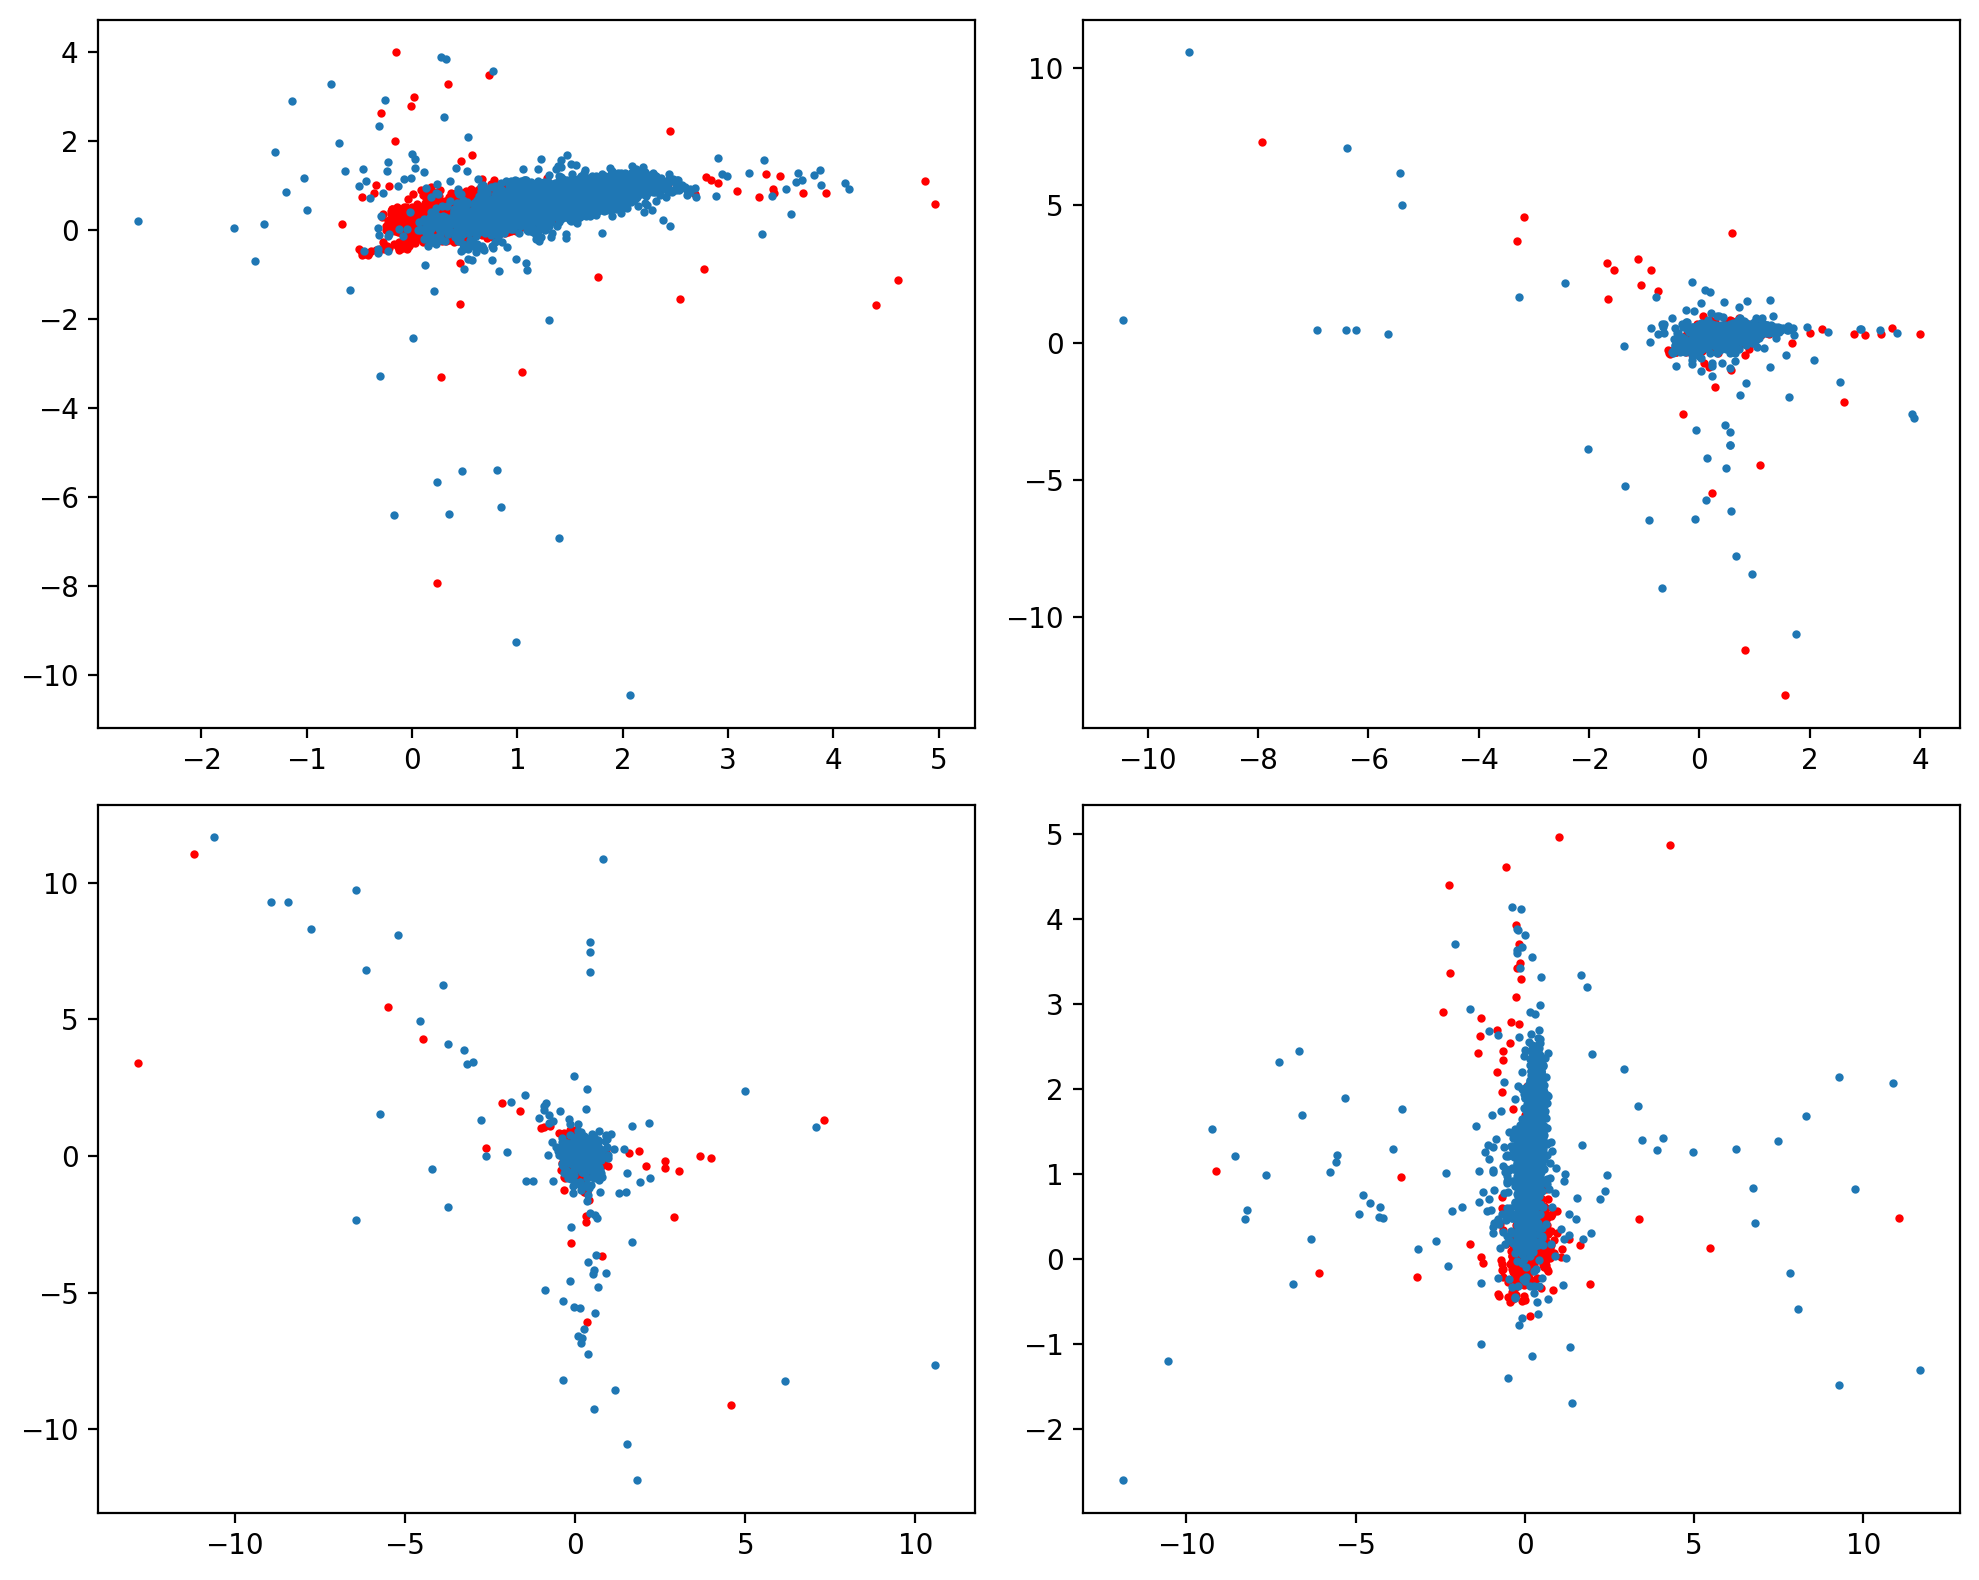

In [10]:
fig, scat = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

scat[0][0].scatter(Q_u_g,Q_g_r, s=4, color = 'red')
scat[0][0].scatter(G_u_g,G_g_r, s=4)

scat[0][1].scatter(Q_g_r,Q_r_i ,s=4, color = 'red')
scat[0][1].scatter(G_g_r,G_r_i ,s=4)

scat[1][0].scatter(Q_r_i, Q_i_z ,s=4, color = 'red')
scat[1][0].scatter(G_r_i, G_i_z ,s=4)

scat[1][1].scatter(Q_i_z, Q_u_g ,s=4, color = 'red')
scat[1][1].scatter(G_i_z, G_u_g ,s=4)

plt.tight_layout()

plt.show()

### Now i have all my dataset divided!

let's classify it without knowing the targets, since the points seems to be gaussian, a gaussian mixture model hsould be appropriate

In [11]:
from astroML.classification import GMMBayes
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from astroML.utils import split_samples
from astroML.utils import completeness_contamination
from sklearn.metrics import precision_recall_curve, roc_curve

(X_train, X_test), (y_train, y_test) = split_samples(data, labels, [0.75, 0.25],random_state=0)
                                                     
predictions = []  #creating predictions array
classifiers = []

N_tot = len(labels)
N_st = np.sum(labels == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr
Ncolors = np.arange(1, data.shape[1] + 1)

#computing the classification by cycling over dimensions
for i in range(np.size(data[0,:])):
    clf = QDA()
    clf.fit(X_train[:, :(i+1)] , y_train)   #fitting with gaussian NB
    
    classifiers.append(clf)
    predictions.append(clf.predict(X_test[:,:(i+1)]))   #filling the predictions array

    
completeness, contamination = completeness_contamination(predictions, y_test)

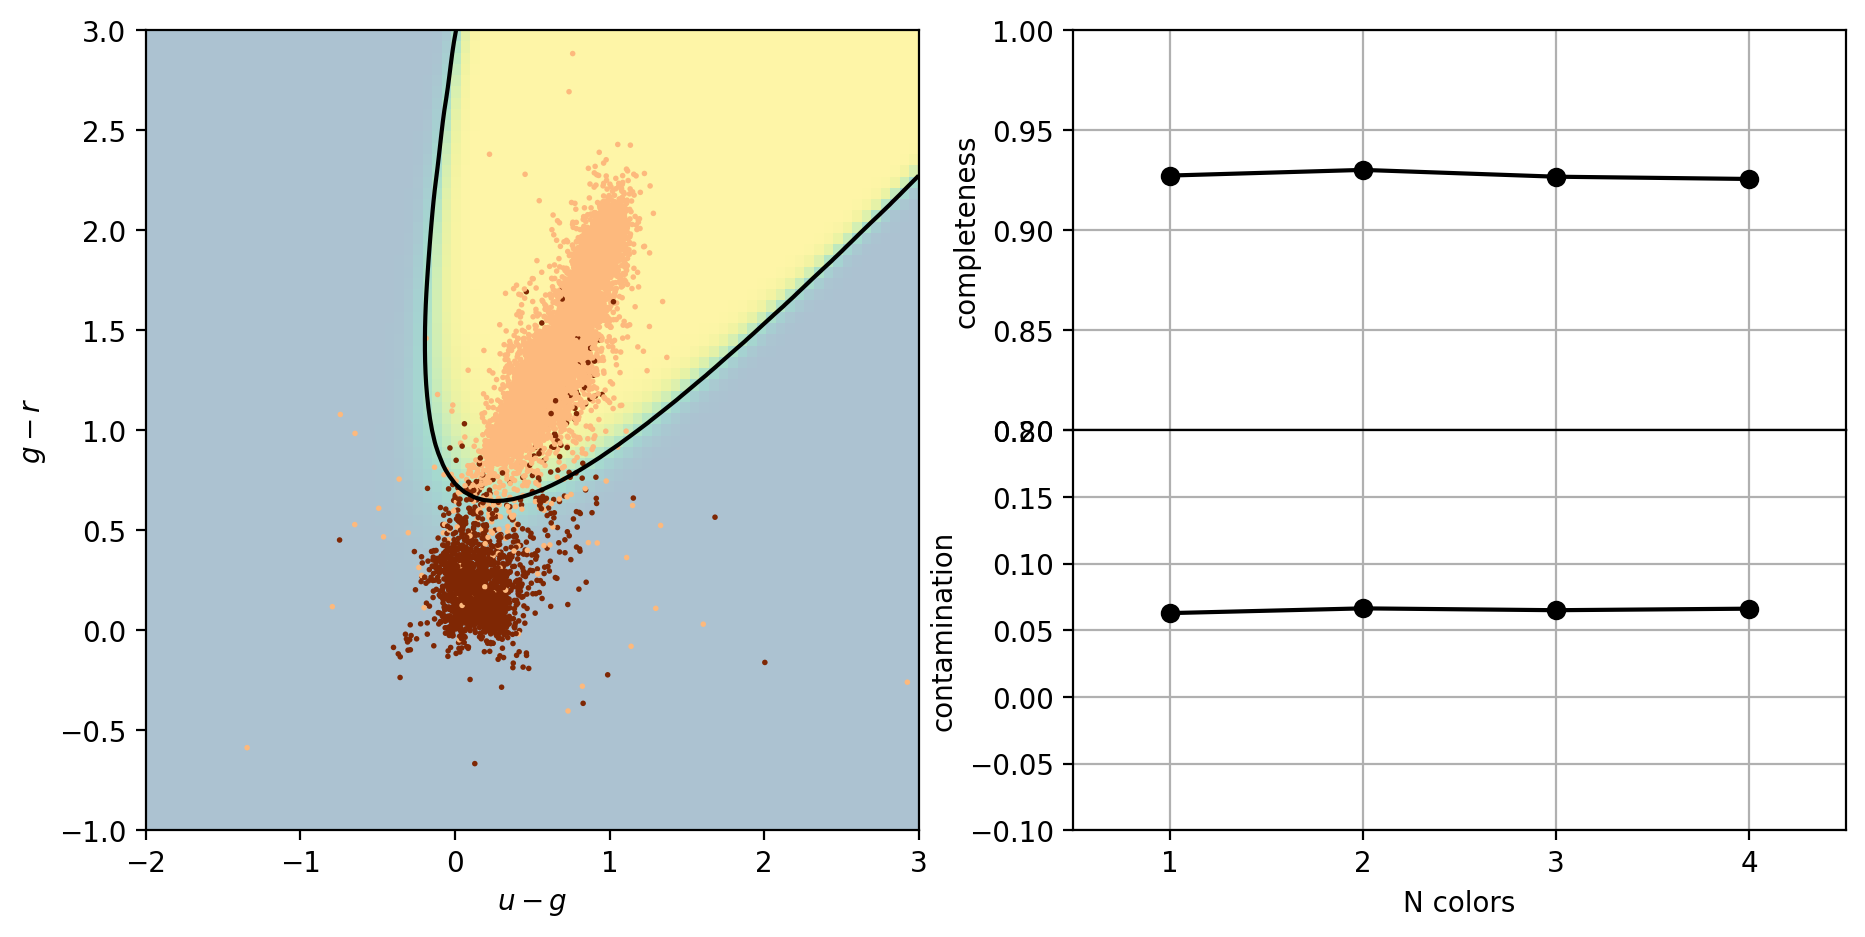

In [12]:
# Compute the decision boundary
clf = classifiers[1]
xlim = (-2, 3)
ylim = (-1, 3)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 81),
                     np.linspace(ylim[0], ylim[1], 71))

Z = clf.predict_proba(np.c_[yy.ravel(), xx.ravel()])
Z = Z[:, 1].reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(data[-N_plot:, 1], data[-N_plot:, 0], c=labels[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z, origin='lower', aspect='auto',cmap='viridis_r', zorder=1,extent=xlim + ylim, alpha = 0.4)
        #plt.cm.binary
im.set_clim(0, 1.5)
ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)



ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')
# Plot completeness vs Ncolors
ax = plt.subplot(222)
ax.plot(Ncolors, completeness, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(0.8, 1.0)
ax.grid(True)

# Plot contamination vs Ncolors
ax = plt.subplot(224)
ax.plot(Ncolors, contamination, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 0.2)
ax.grid(True)

####  let's try with another method

In [23]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

scores = []
classifiers2 = []
predictions2 = []

for i in range(np.size(data[0,:])):
    gmm = GMMBayes((i+1) ,tol=1e-5, covariance_type='full')
    gmm.fit(X_train[:, :(i+1)] , y_train)   #fitting with GMM bayes
    
    classifiers2.append(gmm)
    predictions2.append(gmm.predict(X_test[:,:(i+1)]))   #filling the predictions array

    #CV test
    CVpredk = cross_val_predict(clf, data[:, :(i+1)] , labels)
    scores.append(accuracy_score(labels, CVpredk)) 
    
completeness, contamination = completeness_contamination(predictions2, y_test)

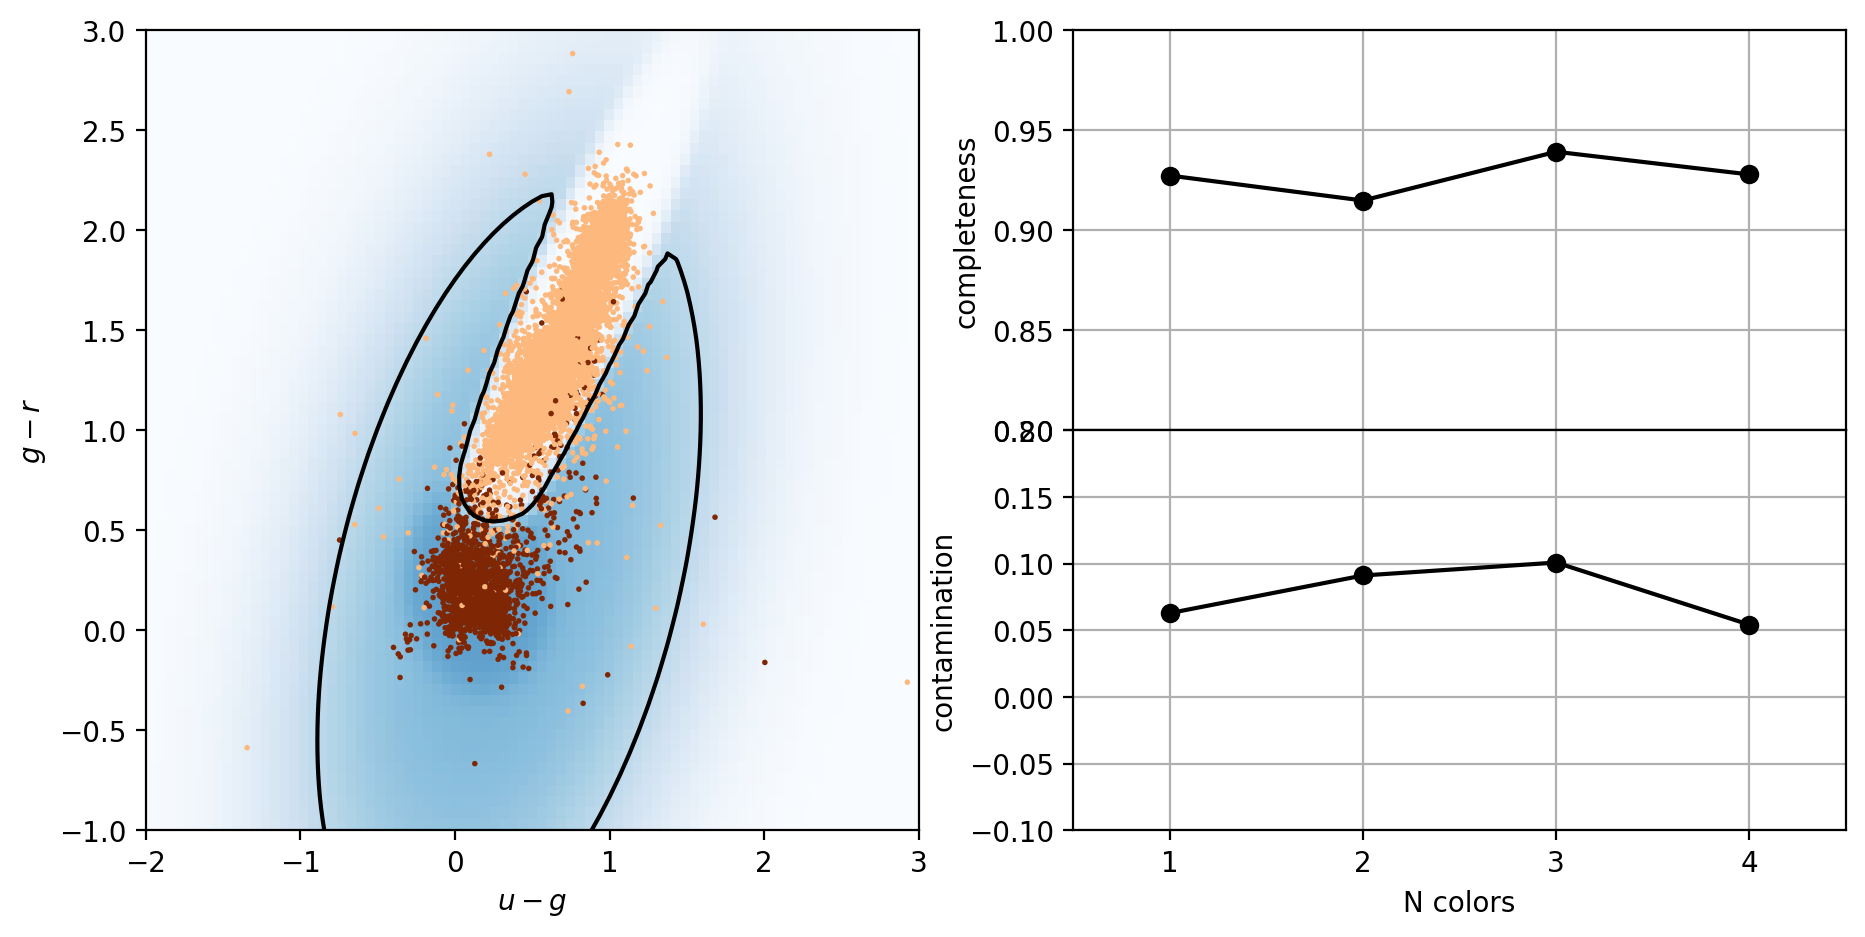

In [24]:
# Compute the decision boundary
gmm = classifiers2[1]
xlim = (-2, 3)
ylim = (-1, 3)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 81),
                     np.linspace(ylim[0], ylim[1], 71))

Z = gmm.predict_proba(np.c_[yy.ravel(), xx.ravel()])
Z = Z[:, 1].reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(data[-N_plot:, 1], data[-N_plot:, 0], c=labels[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z, origin='lower', aspect='auto',cmap='Blues', zorder=1,extent=xlim + ylim, alpha = 0.8)
        #plt.cm.binary
im.set_clim(0, 1.5)
ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)



ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')
# Plot completeness vs Ncolors
ax = plt.subplot(222)
ax.plot(Ncolors, completeness, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(0.8, 1.0)
ax.grid(True)

# Plot contamination vs Ncolors
ax = plt.subplot(224)
ax.plot(Ncolors, contamination, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 0.2)
ax.grid(True)

#### if i had more components the classification would be more precise

what is the number of dimension that gives me the most precise result? it can be useful a CV test


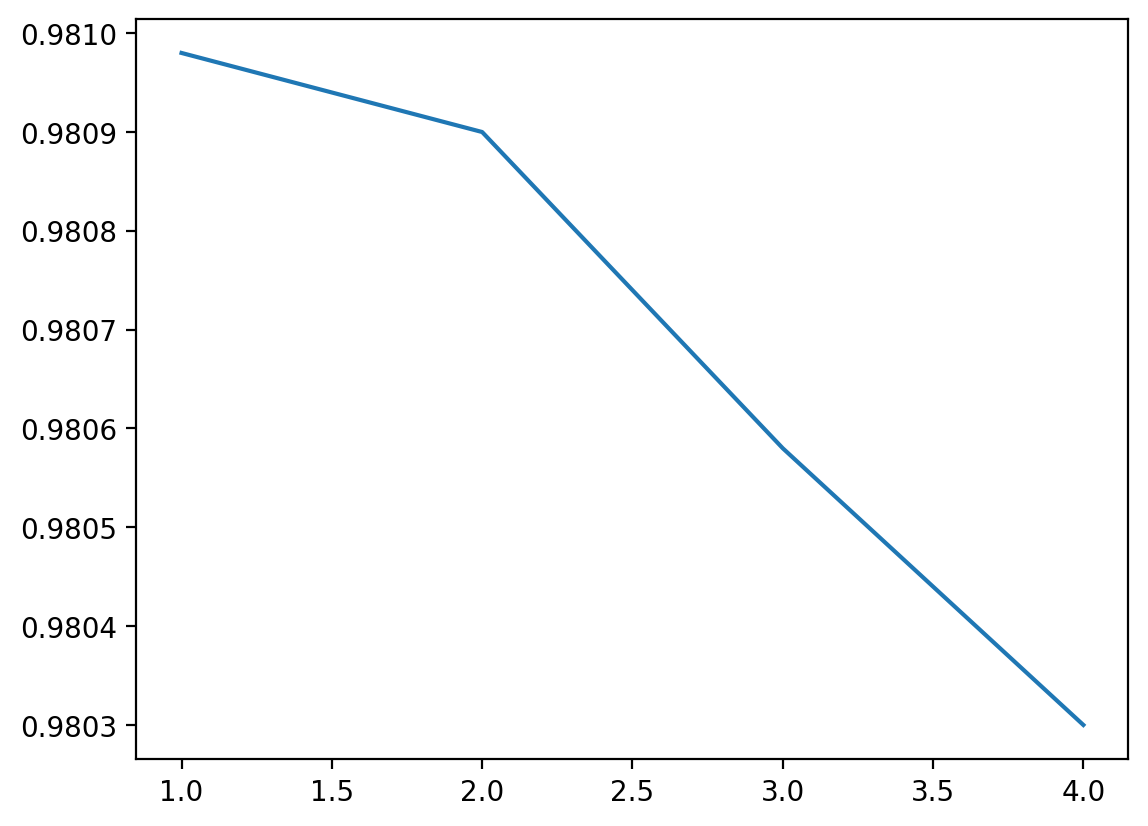

In [25]:
u = np.arange(len(scores))+1
plt.plot(u,scores)